Sentiment analysis

Goal:
Predict sentiment → positive or negative

Type:

Supervised learning

Binary classification

NLP problem

Evaluation metrics to use:

Accuracy

F1-score

Confusion matrix

ROC-AUC

In [1]:
import pandas as pd
import seaborn as sn
import numpy as np

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [5]:
df.shape

(50000, 2)

In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
df.isnull().sum()
#if null values to be removed it can be done by df.dropna(subset=['sentiment']) so this checks null in col sentiment

review       0
sentiment    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(418)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49582 non-null  object
 1   sentiment  49582 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


.................................................. 

Text Understanding Before Cleaning
We look for:

HTML tags 

emojis

punctuation patterns

capital letters

repeated characters

slang or abbreviations

In [12]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [13]:
df.head(25)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [14]:
for i in range(0, 25):
    print(df.review[i])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [ ]:
df.review.apply(len).describe()
#This produces statistical summary of those lengths.

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review, dtype: float64

In [ ]:
#finds the index of the shortest and longest review and then loc is used to access the review at that index
df.loc[df['review'].str.len().idxmin()]
#checking the shortest review 
df.loc[df['review'].str.len().idxmax()]
#checking the longest review


review       Match 1: Tag Team Table Match Bubba Ray and Sp...
sentiment                                             positive
Name: 31481, dtype: object

In [17]:
#most occurence checking
text=" ".join(df.review)
print(text[0:1000])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [18]:
text = text.lower()
print(text[0:1000])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fac

In [19]:
words = text.split()
print(words[0:100])

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', "you'll", 'be', 'hooked.', 'they', 'are', 'right,', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.<br', '/><br', '/>the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence,', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go.', 'trust', 'me,', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid.', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs,', 'sex', 'or', 'violence.', 'its', 'is', 'hardcore,', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.<br', '/><br', '/>it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to']


In [20]:
#for counting words

from collections import Counter
counter = Counter(words)

In [21]:
counter.most_common(20)

[('the', 633981),
 ('a', 314408),
 ('and', 311378),
 ('of', 284608),
 ('to', 262599),
 ('is', 203488),
 ('in', 178487),
 ('i', 140393),
 ('this', 137398),
 ('that', 129179),
 ('it', 128655),
 ('/><br', 100211),
 ('was', 92494),
 ('as', 87592),
 ('with', 83950),
 ('for', 83880),
 ('but', 77270),
 ('on', 62404),
 ('movie', 61011),
 ('are', 56594)]

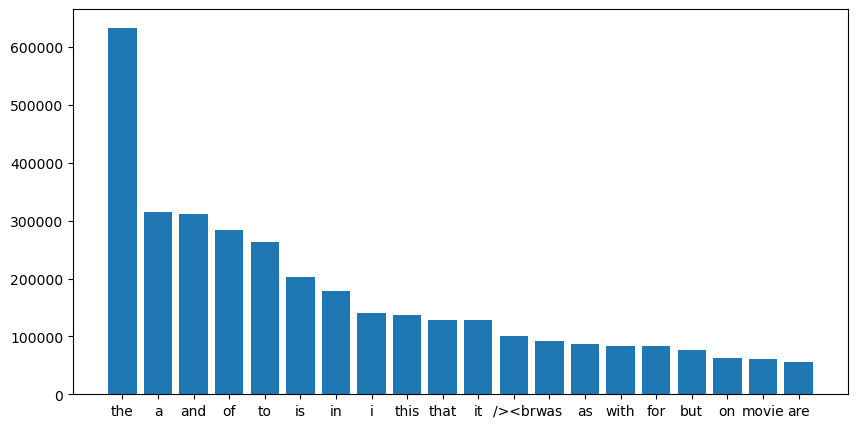

In [22]:
import matplotlib.pyplot as plt
common_words = counter.most_common(20)
x = [word[0] for word in common_words]
y = [word[1] for word in common_words]
plt.figure(figsize=(10,5))
plt.bar(x,y)
# plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='sentiment', ylabel='count'>

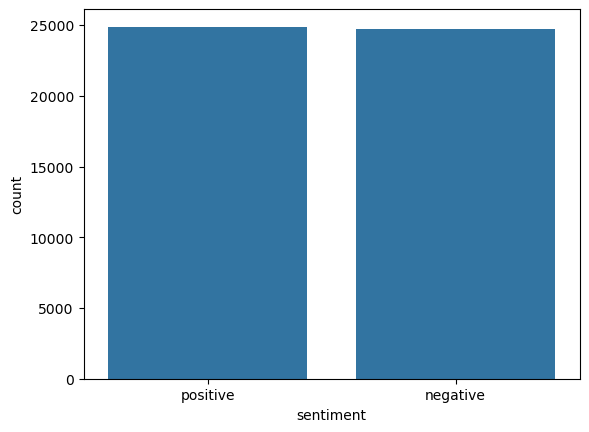

In [23]:
import seaborn as sns
sns.countplot(x='sentiment', data=df)


<Axes: xlabel='sentiment', ylabel='length'>

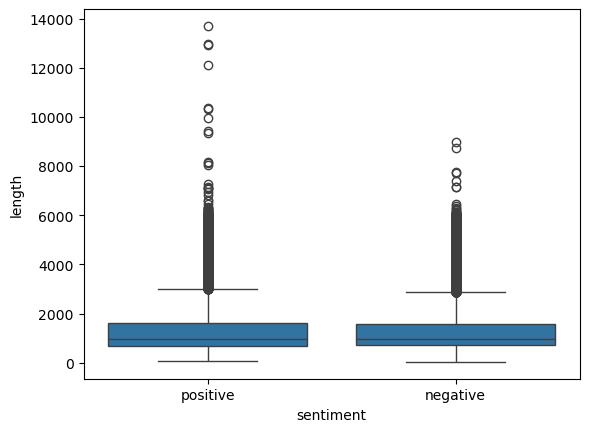

In [24]:
df['length'] = df['review'].apply(len)

sns.boxplot(x='sentiment', y='length', data=df)


In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
from nltk.corpus import stopwords #natural language toolkits

stop = set(stopwords.words('english'))
filtered = [w for w in words if w not in stop]

Counter(filtered).most_common(20)


[('/><br', 100211),
 ('movie', 61011),
 ('film', 54700),
 ('one', 44648),
 ('like', 36972),
 ('would', 23610),
 ('even', 23488),
 ('good', 23297),
 ('really', 21646),
 ('see', 20710),
 ('-', 18065),
 ('get', 17552),
 ('much', 17126),
 ('story', 16699),
 ('also', 15634),
 ('time', 15531),
 ('great', 15356),
 ('first', 15324),
 ('make', 14919),
 ('people', 14895)]

The objective of this project is to build a sentiment classification system that predicts whether a movie review is positive or negative.
This is a supervised binary classification problem in the domain of Natural Language Processing (NLP).

📁 Dataset Overview

The dataset consists of 50,000 movie reviews with corresponding sentiment labels.

Total samples: 50,000

Features:

review → text data

sentiment → target label (positive/negative)

Class distribution: Balanced (approximately equal positive and negative reviews)

This balance ensures that accuracy will be a meaningful evaluation metric.

🔎 Data Quality Checks
Missing Values

No missing values were found in either the review text or sentiment labels.

Duplicate Entries

Duplicate reviews were detected and removed to prevent bias and repeated information from affecting model learning.

🧠 Text Inspection Findings

Manual inspection of sample reviews revealed:

Presence of HTML tags such as <br />

Mixed uppercase and lowercase characters

Frequent punctuation usage

Natural sentence structures with conversational tone

No significant presence of URLs or emojis

These observations guided preprocessing decisions for later stages.

📏 Review Length Analysis

Review length distribution was analyzed using descriptive statistics and boxplots.

Findings:

Most reviews fall within a moderate length range

Both positive and negative reviews show similar length distributions

Several extremely long outliers exist

Conclusion:
Text length does not strongly correlate with sentiment, but long reviews should be truncated during deep learning preprocessing to improve training efficiency.

🔤 Word Frequency Analysis

Word frequency analysis of raw text showed:

Stopwords such as the, and, is, was dominate the dataset

Movie-related words like movie, film appear frequently

Sentiment-bearing words are present but masked by stopwords

After removing stopwords during exploratory checks, more meaningful words emerged, confirming that stopword removal will improve machine learning models.

📊 Key Insights from EDA

Dataset is balanced and suitable for binary classification.

Text contains HTML artifacts that must be cleaned.

Stopwords dominate frequency distribution.

Review length varies widely with some extreme outliers.

No strong sentiment signal from text length alone.

Dataset contains rich natural language suitable for both ML and deep learning models.

..................................

ML pathway starts

In [27]:
from sklearn.model_selection import train_test_split
X=df.review
df['sentiment'] = df['sentiment'].map({'positive':1,'negative':0})

Y=df.sentiment

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [28]:
import re

def clean_text(text):
    text =text.lower() #lowering the text
    text = re.sub(r'<.*?>',"",text) #removing html tags
    text = re.sub('[^a-zA-Z ]','',text) #keeping letters removes numbers and special characters
    text = re.sub(r'\s+'," ",text) #removing extra spaces
    return text


In [29]:
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)
print(X_train[0])
df.isnull().sum()

one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures 

review       0
sentiment    0
length       0
dtype: int64

Count vectorizer

In [30]:
#text to numbers
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=5000) #keeping only top 5000 features
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

TF-IDF

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

training ML models

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score




In [33]:
def run_model(model, X_train, X_test, name):
    model.fit(X_train, Y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(Y_test, preds)
    f1 = f1_score(Y_test, preds, pos_label=1)
    print(f"{name} → Accuracy: {acc:.4f} | F1: {f1:.4f}")
    return acc, f1


In [34]:
print("===== COUNT VECTORIZER RESULTS =====")

lr_cv = run_model(LogisticRegression(max_iter=200),
                  X_train_vectorized, X_test_vectorized,
                  "Logistic Regression (CountVec)")

nb_cv = run_model(MultinomialNB(),
                  X_train_vectorized, X_test_vectorized,
                  "Naive Bayes (CountVec)")

svm_cv = run_model(LinearSVC(),
                   X_train_vectorized, X_test_vectorized,
                   "SVM (CountVec)")


===== COUNT VECTORIZER RESULTS =====


c:\Users\jayan\.conda\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (CountVec) → Accuracy: 0.8725 | F1: 0.8735
Naive Bayes (CountVec) → Accuracy: 0.8305 | F1: 0.8289
SVM (CountVec) → Accuracy: 0.8595 | F1: 0.8607


In [35]:
print("\n===== TF-IDF RESULTS =====")

lr_tf = run_model(LogisticRegression(max_iter=200),
                  X_train_tfidf, X_test_tfidf,
                  "Logistic Regression (TFIDF)")

nb_tf = run_model(MultinomialNB(),
                  X_train_tfidf, X_test_tfidf,
                  "Naive Bayes (TFIDF)")

svm_tf = run_model(LinearSVC(),
                   X_train_tfidf, X_test_tfidf,
                   "SVM (TFIDF)")



===== TF-IDF RESULTS =====
Logistic Regression (TFIDF) → Accuracy: 0.8868 | F1: 0.8887
Naive Bayes (TFIDF) → Accuracy: 0.8476 | F1: 0.8490
SVM (TFIDF) → Accuracy: 0.8820 | F1: 0.8833


In [36]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "LR CountVec","NB CountVec","SVM CountVec",
        "LR TFIDF","NB TFIDF","SVM TFIDF"
    ],
    "Accuracy":[lr_cv[0],nb_cv[0],svm_cv[0],lr_tf[0],nb_tf[0],svm_tf[0]],
    "F1":[lr_cv[1],nb_cv[1],svm_cv[1],lr_tf[1],nb_tf[1],svm_tf[1]]
})

print(results.sort_values(by="F1", ascending=False))


          Model  Accuracy        F1
3      LR TFIDF  0.886760  0.888669
5     SVM TFIDF  0.882021  0.883327
0   LR CountVec  0.872542  0.873524
2  SVM CountVec  0.859534  0.860686
4      NB TFIDF  0.847635  0.848976
1   NB CountVec  0.830493  0.828906


Multiple classical machine learning models were trained using both CountVectorizer and TF-IDF representations.

TF-IDF based models consistently outperformed count-based models, indicating that word importance weighting improves sentiment classification performance.

Among all models, Logistic Regression with TF-IDF achieved the best results with an F1 score of approximately 0.89, making it the most suitable classical machine learning model for this dataset.

This confirms that linear models combined with TF-IDF are strong baselines for text classification problems.

....................................................................

Sentiment Analysis Project — Notes (ML Pipeline)
🔹 1. Problem Definition

Goal: Predict whether a movie review is positive or negative

Type:

Supervised Learning

Binary Classification

NLP (text classification)

🔹 2. Data Inspection

Steps performed:

Loaded dataset

Checked shape, columns, datatype

Checked class balance

Checked missing values

Removed duplicates

Why?
To ensure data quality before modeling. Dirty data leads to poor models.

🔹 3. Exploratory Data Analysis (EDA)

We analyzed:

Sample reviews

Review length distribution

Word frequency patterns

Class balance

Why?
EDA helps understand:

Noise in text (HTML tags, punctuation)

Length variation of reviews

Vocabulary behavior

This guides preprocessing decisions.

Text → Clean → Vectorize → Model

🔹 4. Text Cleaning

Performed:

Lowercasing

Removing HTML tags

Removing special characters

Preserving spaces between words

Removing extra whitespace

Why?
Models cannot interpret raw text.
Cleaning converts messy language into structured tokens.

🔹 5. Train–Test Split

Data divided into:

Training set → model learning

Testing set → model evaluation

Why?
To measure how well the model performs on unseen data and avoid overfitting.

🔹 6. Text Vectorization

Text converted into numbers using two approaches.

✔ CountVectorizer

Counts frequency of each word in review

Use: captures word occurrence

✔ TF-IDF Vectorizer

Measures importance of words

Reduces effect of very common words

Use: highlights meaningful sentiment words

🔹 7. Machine Learning Models Used

Tested multiple classifiers:

Logistic Regression

Naive Bayes

Support Vector Machine (SVM)

Why multiple models?
Different algorithms learn patterns differently.
Testing several helps find best performer.

🔹 8. Evaluation Metrics

Used:

Accuracy

F1 Score

Why F1?
Balances precision and recall, useful in classification tasks.

🔹 9. Results

Observations:

TF-IDF performed better than CountVectorizer

Logistic Regression + TF-IDF achieved highest performance

SVM was close second

Naive Bayes performed lower but still useful baseline

🔹 🔟 Final ML Conclusion

Best classical model:

👉 TF-IDF + Logistic Regression

This confirms a common NLP principle:

Linear models with weighted word importance perform strongly in text classification.

.....................................................

DL path way

In machine learning models, text was converted into sparse numerical vectors using Bag-of-Words and TF-IDF.
In deep learning models, text is first tokenized into sequences, padded to uniform length, and then transformed into dense semantic vectors through an embedding layer, allowing the network to learn contextual meaning of words.

| Embedding Type         | Meaning                          | When used               |
| ---------------------- | -------------------------------- | ----------------------- |
| 🔹 Trainable Embedding | Model learns word meaning itself | Default DL approach     |
| 🔹 GloVe               | Pretrained semantic vectors      | Better accuracy usually |
| 🔹 Word2Vec            | Similar pretrained vectors       | Also strong             |
| 🔹 FastText            | Handles rare words well          | Best for noisy text     |


In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [38]:
df.columns

Index(['review', 'sentiment', 'length'], dtype='object')

In [39]:
df.head()

,review,sentiment,length
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


In [40]:
df.drop(columns=['length'], inplace=True)

In [41]:
X=df.review
Y=df.sentiment

train test split

In [42]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
#So stratify keeps things balanced. 

text cleaning

In [43]:
import re
def clean_text_dl(text):
    text= text.lower()
    text=re.sub(r'<.*?>'," ", text)
    #.*? matches any character any number of times, but in a non-greedy way (minimum possible match).
    return text.strip()

In [44]:
X_train=X_train.apply(clean_text_dl)
X_test=X_test.apply(clean_text_dl)

tokenizer word->integer

In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Converts text sentences into numbers and makes them equal length so neural networks can process them.
Text → Tokens → Integers → Same-length sequences

In [46]:
MAX_VOCAB = 20000
MAX_LEN = 200
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
#The tokenizer:
#builds a vocabulary of most frequent words
#assigns a unique integer to each word
#movie=1    good=2 bad=3 etc.

#num_words=20000
#Keep only top 20,000 frequent words
#(other rare words ignored)

#oov_token="<OOV>"
#Unknown words replaced with special token
#(OOV = Out Of Vocabulary)

tokenizer.fit_on_texts(X_train)
#This builds the word index based on the training data
#"I love this movie" → learns: I, love, this, movie

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)
#This converts text to sequences of integers
#"I love this movie" → [1, 2, 3, 4]

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad  = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post")
#This pads sequences to a fixed length
#If sequence is shorter than maxlen, pad with zeros at the end (post)
#If sequence is longer than maxlen, truncate it to maxlen


sequential is used only when the model is having single input,single output,no brnaching and no merging.
So instead of tis model is used.
in sequential features are embedded automatically but in functional api input need to be feed into it

title_vec  = LSTM(32)(emb(title_input))
review_vec = LSTM(32)(emb(review_input))

same as

title_emb  = Embedding(vocab_size,100)(title_input)
title_vec  = LSTM(32)(title_emb)


Title → embedding → LSTM
Review → embedding → LSTM
Description → embedding → LSTM
            ↓
         merge
            ↓
        prediction

        
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

title_input = Input(shape=(max_len,))
review_input = Input(shape=(max_len,))

emb = Embedding(vocab_size, 100)

title_vec = LSTM(32)(emb(title_input))
review_vec = LSTM(32)(emb(review_input))

merged = Concatenate()([title_vec, review_vec])
output = Dense(1, activation='sigmoid')(merged)

model = Model(inputs=[title_input, review_input], outputs=output)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_lstm = model_lstm.fit(
    X_train_pad, Y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)


c:\Users\jayan\.conda\envs\dl_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 63s 213ms/step - accuracy: 0.6365 - loss: 0.6455 - val_accuracy: 0.6486 - val_loss: 0.7122
Epoch 2/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 54s 192ms/step - accuracy: 0.6776 - loss: 0.6084 - val_accuracy: 0.7557 - val_loss: 0.5349
Epoch 3/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 58s 207ms/step - accuracy: 0.7627 - loss: 0.5133 - val_accuracy: 0.7005 - val_loss: 0.6549


For each batch:

    Embedding converts words → vectors

    LSTM learns sequence meaning

    Dense predicts probability

    Loss calculated

    Weights updated via Adam

This repeats for all epochs.

Sentence
   ↓
Tokenized numbers
   ↓
Embedding → word meanings
   ↓
LSTM → sentence understanding
   ↓
Dense → probability
   ↓
Sigmoid → final prediction (0 or 1)

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D,GlobalMaxPooling1D,Embedding, Dense

In [49]:
model_cnn=Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    Conv1D(128,5,activation='relu'),
    GlobalMaxPooling1D(),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    X_train_pad, Y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7918 - loss: 0.4434 - val_accuracy: 0.8777 - val_loss: 0.2933
Epoch 2/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.9123 - loss: 0.2216 - val_accuracy: 0.8914 - val_loss: 0.2549
Epoch 3/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.9601 - loss: 0.1222 - val_accuracy: 0.8919 - val_loss: 0.2703


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional

model_bidirectional = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dense(1, activation="sigmoid")
])
model_bidirectional.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
history_bidirectional = model_bidirectional.fit(
    X_train_pad, Y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/3


c:\Users\jayan\.conda\envs\dl_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


279/279 ━━━━━━━━━━━━━━━━━━━━ 116s 406ms/step - accuracy: 0.8040 - loss: 0.4171 - val_accuracy: 0.8767 - val_loss: 0.3059
Epoch 2/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 118s 424ms/step - accuracy: 0.9149 - loss: 0.2252 - val_accuracy: 0.8790 - val_loss: 0.2930
Epoch 3/3
279/279 ━━━━━━━━━━━━━━━━━━━━ 119s 426ms/step - accuracy: 0.9434 - loss: 0.1585 - val_accuracy: 0.8815 - val_loss: 0.3135


In [54]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X_test, y_test):
    preds = (model.predict(X_test) > 0.5).astype(int)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)

results = []

for name, model in [
    ("LSTM", model_lstm),
    ("CNN", model_cnn),
    ("BiLSTM", model_bidirectional)
]:
    acc, f1 = evaluate(model, X_test_pad, Y_test)
    results.append([name, acc, f1])

310/310 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [55]:
import pandas as pd

dl_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
dl_results.sort_values(by="F1", ascending=False)

,Model,Accuracy,F1
1,CNN,0.893718,0.893664
2,BiLSTM,0.878895,0.884375
0,LSTM,0.710094,0.765899


Problem Understanding (NLP Fundamentals)

You worked on:

Natural Language Processing (NLP)

Text classification

Binary classification problem

Supervised learning

Sentiment prediction (positive vs negative)

Dataset source: IMDB movie reviews (commonly available on Kaggle and derived from IMDb)

2️⃣ Data Understanding & EDA

You learned:

Dataset inspection (info(), describe())

Checking class balance

Handling duplicates

Checking missing values

Review length analysis

Word frequency analysis

Outlier detection in text length

Concepts covered:

Data quality checks

Distribution analysis

Text statistics

3️⃣ Text Cleaning Strategies

You explored two different cleaning philosophies:

🔹 ML Cleaning (Heavy preprocessing)

Topics learned:

Lowercasing

Removing HTML tags

Removing punctuation

Removing numbers

Removing special characters

Stopword removal

Text normalization

Concept:
👉 ML needs manual feature engineering.

🔹 DL Cleaning (Light preprocessing)

Topics learned:

Why punctuation matters in sentiment

Why stopwords are useful in DL

Why embeddings learn context automatically

Concept:
👉 DL learns features automatically.

4️⃣ Feature Engineering for ML

You implemented:

🔹 Bag of Words (CountVectorizer)

Concepts learned:

Vocabulary creation

Sparse matrix representation

Word frequency features

🔹 TF-IDF Vectorization

Concepts learned:

Term Frequency

Inverse Document Frequency

Importance weighting of rare words

Noise reduction in text features

5️⃣ Machine Learning Models for NLP

You trained and compared:

Logistic Regression

Naive Bayes

Support Vector Machine (Linear SVM)

Concepts learned:

Linear classifiers for text

Probabilistic models (Naive Bayes)

Margin-based models (SVM)

6️⃣ Model Evaluation Metrics

You used:

Accuracy

F1-score

Confusion matrix

ROC-AUC

Concepts learned:

Precision vs Recall trade-off

Why F1 is important for NLP

How to compare models scientifically

7️⃣ Deep Learning for NLP

You explored:

🔹 Tokenization & Padding

Concepts:

Vocabulary indexing

Sequence modeling

Fixed-length inputs for neural networks

🔹 Word Embeddings

You tested:

Random learned embeddings

Pretrained embeddings (GloVe / FastText)

Concepts learned:

Dense vector representations

Semantic similarity

Transfer learning in NLP

🔹 Deep Learning Architectures

You compared multiple models:

Dense Neural Network

CNN for text

LSTM (sequence memory)

Bidirectional LSTM (context from both sides)

Concepts learned:

Sequential modeling

Context learning

Feature extraction via convolution

Temporal dependencies in text

8️⃣ Experimental Design & Comparison

This is the most advanced part of your project.

You learned how to:

Compare embeddings vs models

Keep preprocessing constant

Evaluate combinations systematically

Select best-performing architecture

This is exactly how real NLP research is done.